<a href="https://colab.research.google.com/github/MohammadHHasan2/ME4452/blob/main/Linear%20Regression/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**This handout is heavily based on the online web resource *Machine Learning for Mechanical Engineering* by Mark Fuge and uses their code and examples. All credit for the code is given to the original source. This document merely adapts the code as a jupyter notebook for ease of use. You may see the full course in the following link: https://ideal.umd.edu/ML4ME_Textbook/.**

# Introduction

Models of the real world are constructed from and validated by data. Data, however, is seldom clean as it always includes noise, sensor error, nonlinear effects. Regression models allow fitting data to a model in an efficient way while minimizing unintended effects. In this section, we study different simple regression models:

- item Polynomial Regression (single and multi-variate)
- item Logistic Regression

These regression models will help us identify important concepts in machine learning before studying more advanced machine learning concepts.

# Polynomial Regression

## Single variate Linear Regression

Suppose data from an experimental test follows figure 1. The data should follow a sinusoidal profile. The actual data is scattered about the sinusoidal profile. Let's try to find ways to fit a curve to the data to create a model for unavailable datapoints. We may start by using a linear fit:

<p align="center">
  <img src="https://raw.githubusercontent.com/MohammadHHasan2/ME4452/main/Linear%20Regression/Assets/ExperimentalDataAndModel.png" width="500">
</p>

$y = w^T \textbf{x}$

Where $\textbf{w}$ is some weight vector and $\textbf{x}$ is the feature vector. For linear regression, this vector is $[1, x]$. The first element is used for the bias of regression (the y-intercept).



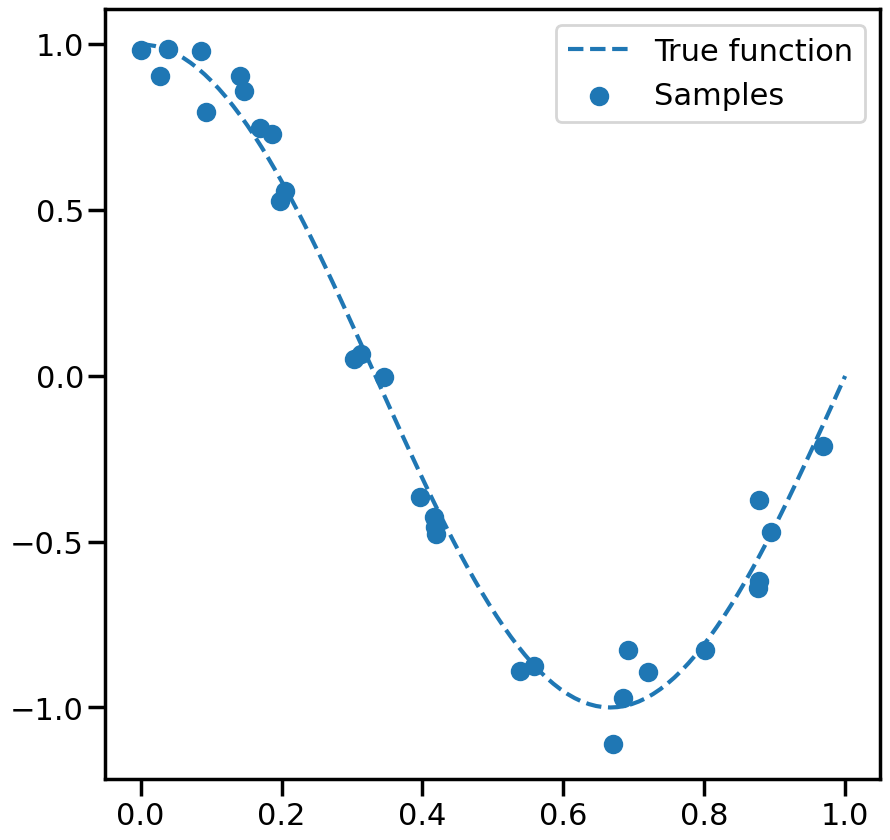

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import SGDClassifier
from ipywidgets import interact,interact_manual, FloatSlider
from sklearn.datasets import make_regression
import seaborn as sns
sns.set_context('poster')
np.random.seed(1)

# Number of data points
n_samples = 30

# True Function we want to estimate
true_fun = lambda X: np.cos(1.5 * np.pi * X)

# Noisy Samples from the true function
X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1

plt.figure(figsize=(10,10))
# Plot the true function:
X_plot = np.linspace(0, 1, 100)
plt.plot(X_plot, true_fun(X_plot), '--',label="True function")
# Plot the data samples
plt.scatter(X,y, label="Samples")
plt.legend(loc="best")
plt.show()

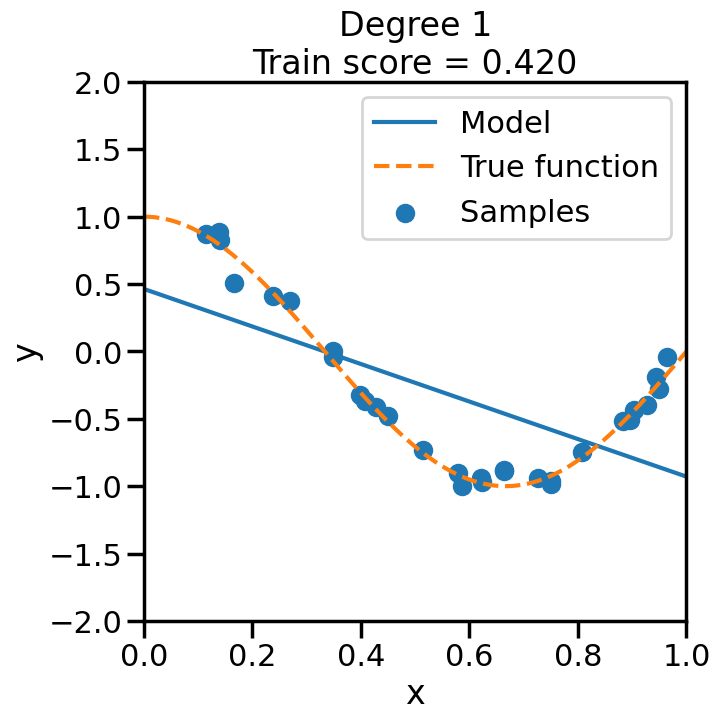

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Here is a list of different degree polynomials to try out
degrees = [1]

# Generate samples of the true function + noise
X = np.sort(np.random.rand(n_samples))
noise_amount = 0.1
y = true_fun(X) + np.random.randn(n_samples) * noise_amount

# For each of the different polynomial degrees we listed above
d = 1
plt.figure(figsize=(7, 7)) # Make a new figure
    # Construct the polynomial features
polynomial_features = PolynomialFeatures(degree=d,
                                             include_bias=False)
    # Construct linear regression model
linear_regression = LinearRegression()
pipeline = Pipeline([("polynomial_features", polynomial_features),
                         ("linear_regression", linear_regression)])
    # Now fit the data first through the
    # polynomial basis, then do regression
pipeline.fit(X[:, np.newaxis], y)

    # Get the accuracy score of the trained model
    # on the original training data
score = pipeline.score(X[:, np.newaxis],y)

    # Plot the results
X_plot = np.linspace(0, 1, 100)
plt.plot(X_plot, pipeline.predict(X_plot[:, np.newaxis]), label="Model")
plt.plot(X_plot, true_fun(X_plot), '--',label="True function")
plt.scatter(X, y, label="Samples")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim((0, 1))
plt.ylim((-2, 2))
plt.legend(loc="best")

    # Print the polynomial degree and the training
    # accuracy in the title of the graph
plt.title("Degree {}\nTrain score = {:.3f}".format(
        d, score))
plt.show()

## Polynomial Fit for Single Variate Functions

Notice that the results are less than ideal. This is due to actual function being less than linear. We may modify our equation above to fit to any polynomial function as follows:

$y = \textbf{w}^T\textbf{x}$

where now $\textbf{x} = [1,x,x^2,...,x^n]$ is a vector of the exponents of the powers of the input value up to the nth power and $\textbf{w}$ is an n+1 vector. This produces a polynomial regression of the nth order to fit the data. Let's see how each polynomial fit our data

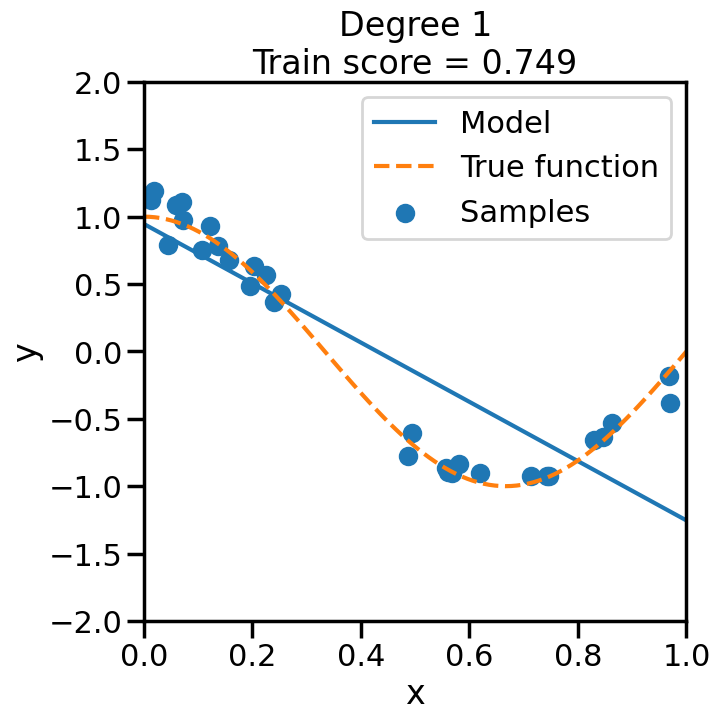

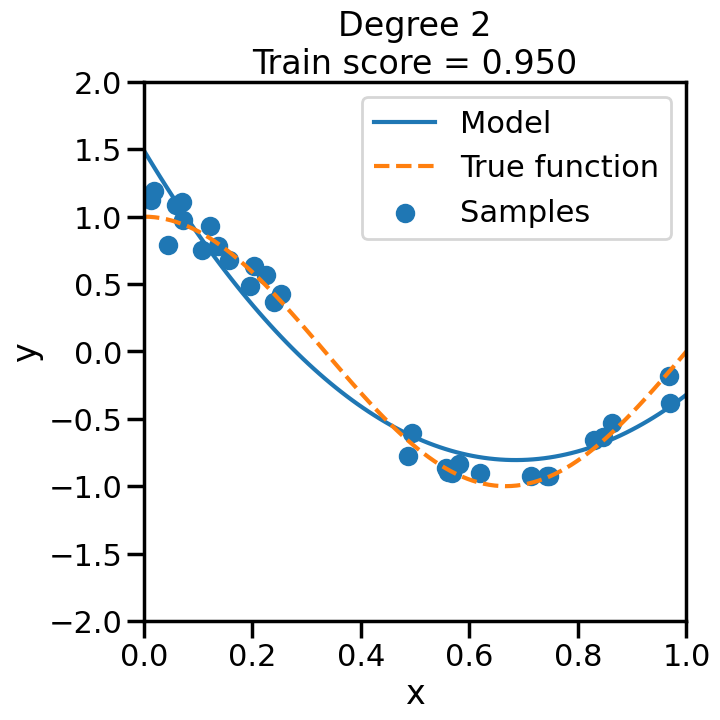

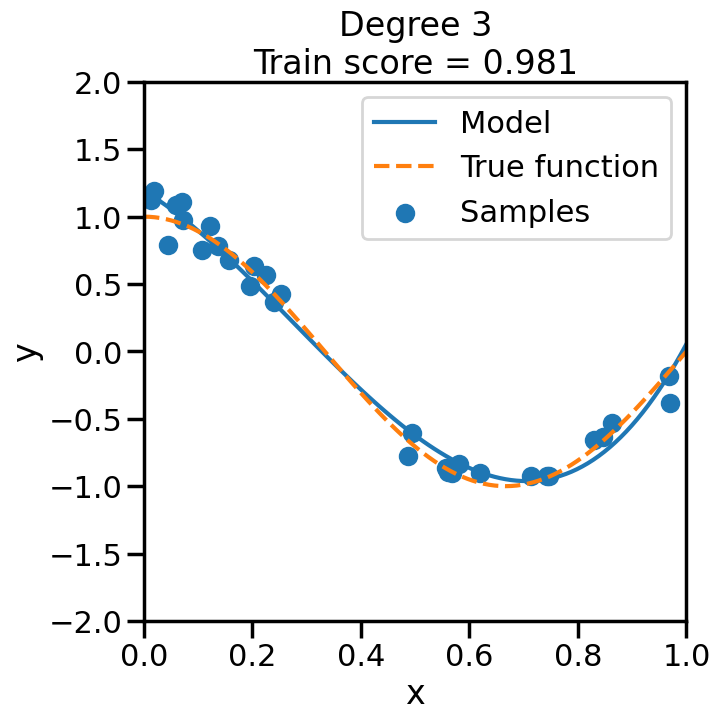

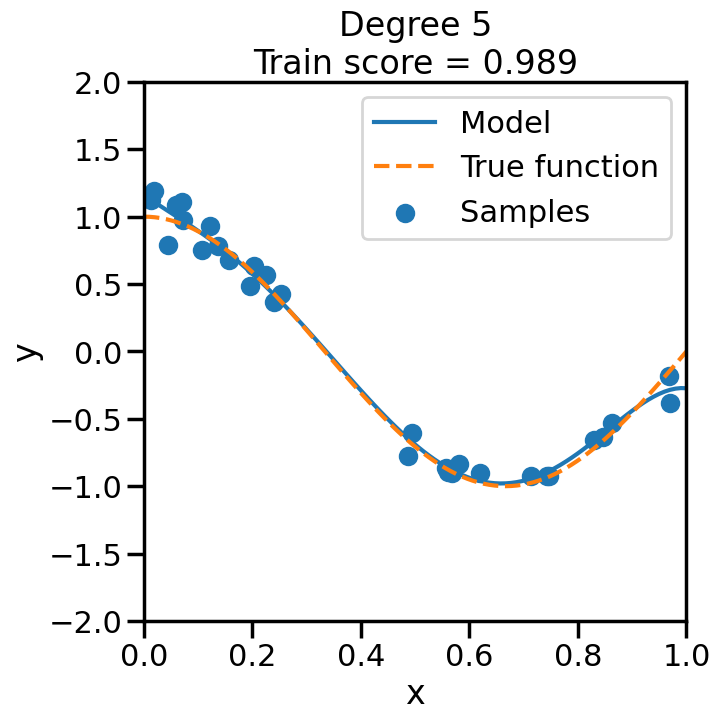

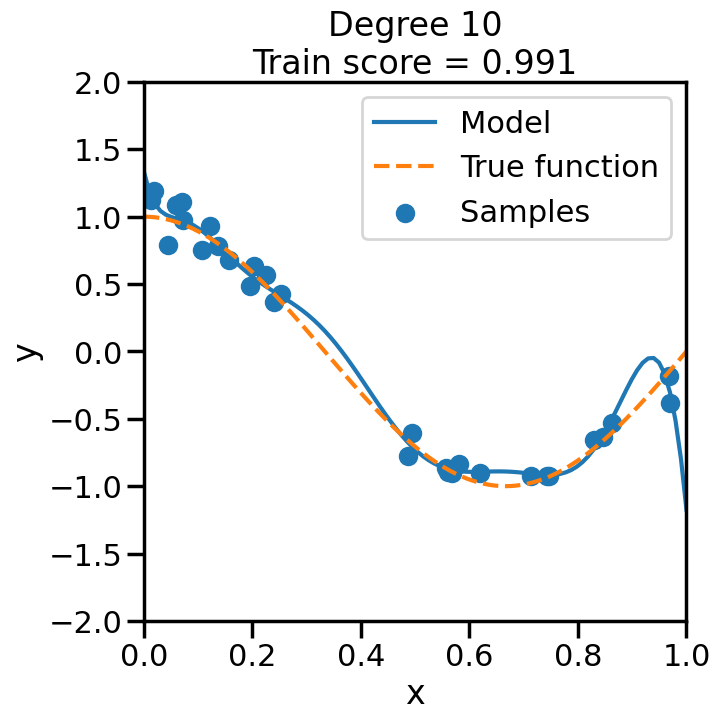

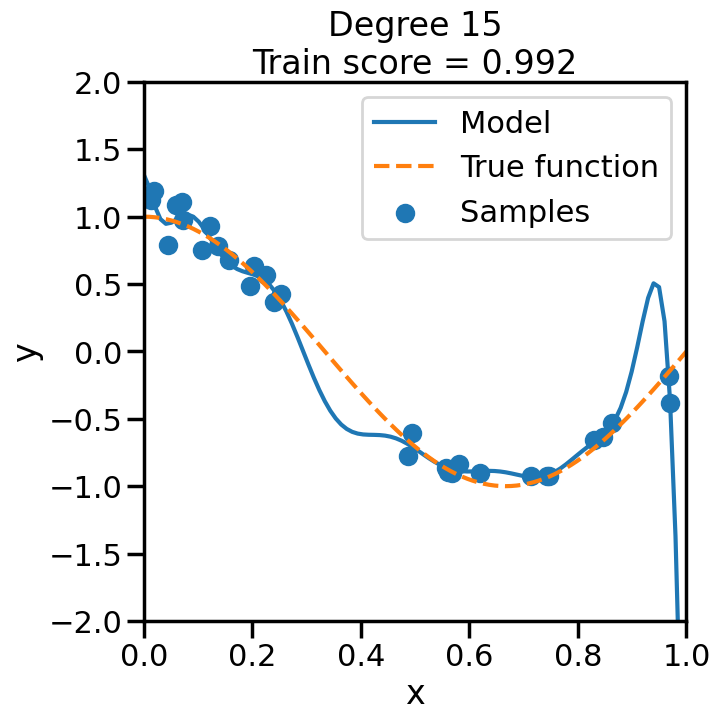

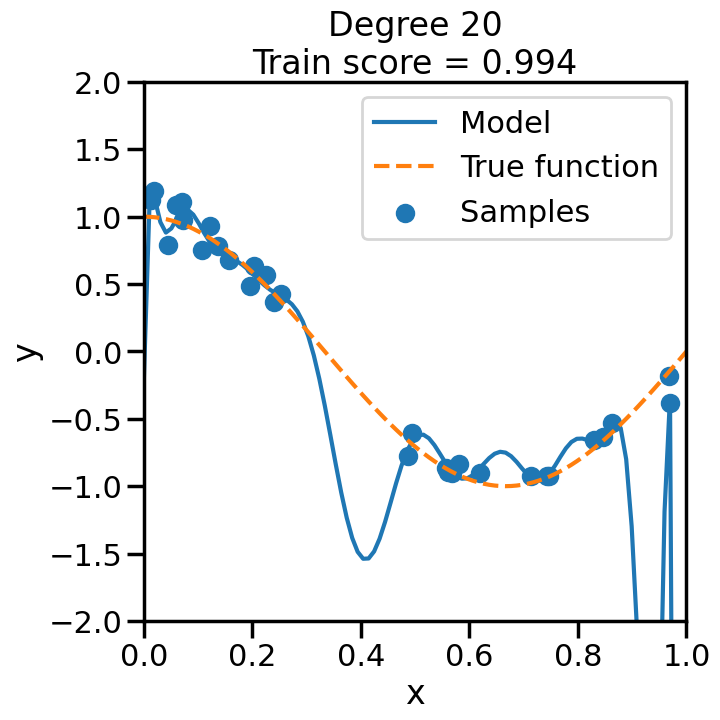

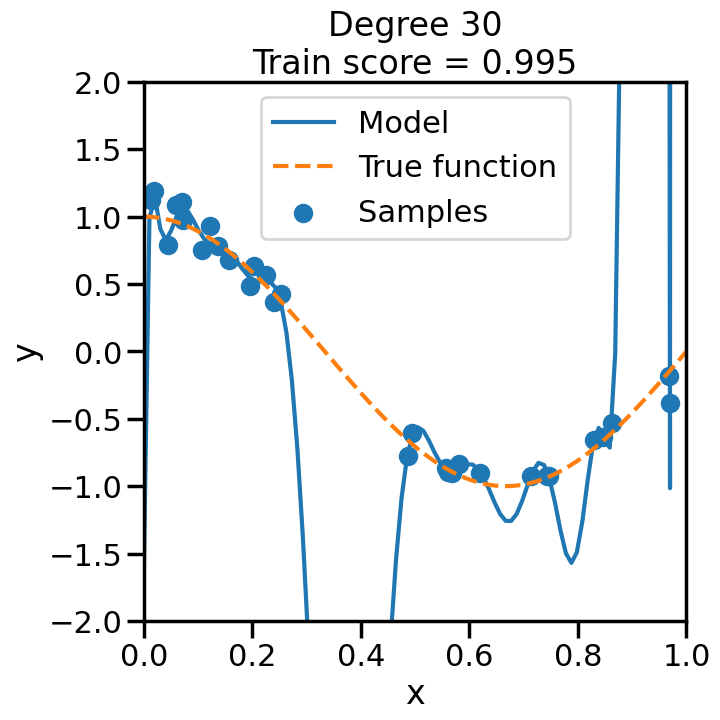

In [ ]:
degrees = [1,2,3,5,10,15,20,30]
# For each of the different polynomial degrees we listed above
for d in degrees:
    plt.figure(figsize=(7, 7)) # Make a new figure
    # Construct the polynomial features
    polynomial_features = PolynomialFeatures(degree=d,
                                             include_bias=False)
    # Construct linear regression model
    linear_regression = LinearRegression()
    pipeline = Pipeline([("polynomial_features", polynomial_features),
                         ("linear_regression", linear_regression)])
    # Now fit the data first through the
    # polynomial basis, then do regression
    pipeline.fit(X[:, np.newaxis], y)

    # Get the accuracy score of the trained model
    # on the original training data
    score = pipeline.score(X[:, np.newaxis],y)

    # Plot the results
    X_plot = np.linspace(0, 1, 100)
    plt.plot(X_plot, pipeline.predict(X_plot[:, np.newaxis]), label="Model")
    plt.plot(X_plot, true_fun(X_plot), '--',label="True function")
    plt.scatter(X, y, label="Samples")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc="best")

    # Print the polynomial degree and the training
    # accuracy in the title of the graph
    plt.title("Degree {}\nTrain score = {:.3f}".format(
        d, score))
    plt.show()

The polynomial fits above vary in performance. Increasing the polynomial degree improves performance only to a point. Beyond that, the performance becomes noticably worse. This occurs due to a phenomenon called *overfitting*, a very common issue in machine learning systems that arises due to the model having too much dimensionality and attempting to fit the full data, noise included.

We will get to different ways to dealing with overfitting problems. First, lets explore how data is used to train our linear regression model.

### Loss functions

In linear regression (and other machine learning approaches), learning happens by optimizing some tunable parameters. Here, the tunable parameters are $\textbf{w}$ and they are tuned by minimizing a cost function. A very common cost function is the *Mean Squared Error* (MSE)

$MSE = \frac{1}{N}\sum_{i=1}^N(y_i-\hat{y_i})^2$

Note that its a lot easier to compute this summation using the inner product through vectors

$MSE = \frac{1}{N}(\mathbf{Y}-\mathbf{\hat{Y}})^T(\mathbf{Y}-\mathbf{\hat{Y}})$

For a degree 1 polynomial fit, one may find the weights using:

$w = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^Ty$

## Linear Classification

The function introduced in this chapter can be used for more than regression and the computation of numerical outputs. It turns out, one may use polynomials to classify data into different categories. Consider the data below.

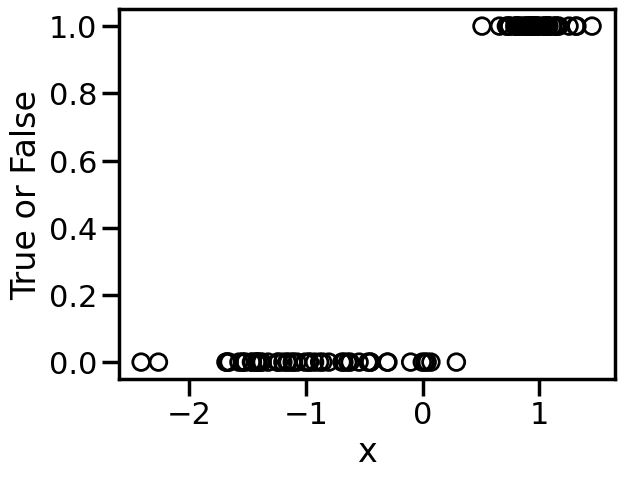

In [ ]:
from sklearn.datasets import make_classification
X, y = make_classification(n_features=1, n_redundant=0,
                           n_informative=1,
                           random_state=1,
                           n_clusters_per_class=1,
                           flip_y=0.0, class_sep=1)
plt.figure()
plt.xlabel('x')
plt.ylabel('True or False')
plt.scatter(X,y,marker='o',facecolors='none',edgecolors='k')
plt.show()

Here, suppose that two categories exist: True (numerical value of 1) and false (numerical value of 0). One wants to find a function that takes the input x as an argument and return either True or False. In this case, a linear fit is used as a part of a sigmoidal function which helps with classification. A sigmoidal function is a popular function in machine learning which uses the following function:

$\sigma(x) = \frac{1}{1+e^{\mathbf{w}^T\mathbf{x}}}$

The sigmoidal function is bounded between 0 and 1, somewhat like the probability of an action, thus, the output of the sigmoidal function can be thought of as a probability. This application of linear regression is called logistic regression.

To classify objects, much like shown above, the output $y$ is either 0 or 1 typically. A standard loss function to be used in this application, thus, is a log loss function, for the output $k$ of the classifier is given by:

$\text{Log Loss} = \begin{cases}
      -\text{ln}(p_k) & y_k = 1 \\
      -\text{ln}(1-p_k) & y_k = 0
   \end{cases}$

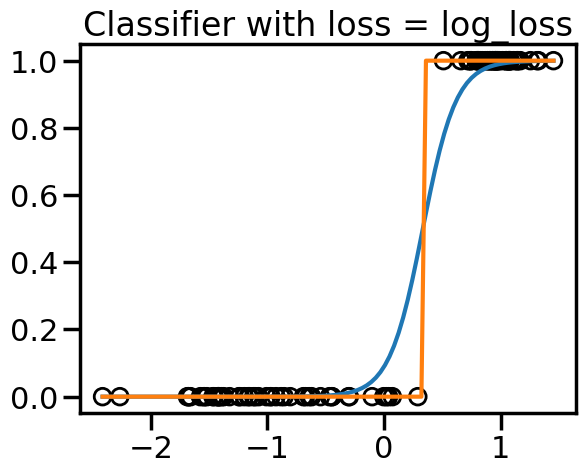

In [ ]:
####### Try Changing the Below ######
#loss = 'squared_error'
loss = 'log_loss'
#loss = 'hinge'
#####################################

model = SGDClassifier(loss=loss, fit_intercept=True, max_iter = 2000,
                     penalty='l2', alpha=.001, epsilon=1, tol=1e-3) #This is a classifier
model.fit(X, y)
Xp = np.linspace(X.min(),X.max(),100)
Xp = Xp[:, np.newaxis]
plt.figure()
plt.scatter(X,y,marker='o',facecolors='none',edgecolors='k')
try:
    plt.plot(Xp,model.predict_proba(Xp)[:,1],label='probability')
except:
    pass
plt.plot(Xp,model.predict(Xp))
plt.title("Classifier with loss = {}".format(loss))
plt.show()